<a href="https://colab.research.google.com/github/Yash2004Codes/Kaggle-Heart-Disease-Feb/blob/main/Kaggle_Feb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Train a logistic regression model using `train.csv`, make predictions on `test.csv`, and generate a Kaggle submission file.

## Load Data

### Subtask:
Load the 'train.csv' and 'test.csv' files into pandas DataFrames.


**Reasoning**:
Load the 'train.csv' and 'test.csv' files into pandas DataFrames and display their first few rows to verify the loading.



In [54]:
# cell 1
import pandas as pd

train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("Train DataFrame head:")
print(train_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Train DataFrame head:
   id   Age  Sex  Chest pain type     BP  Cholesterol  FBS over 120  \
0   0  58.0  1.0              4.0  152.0        239.0           0.0   
1   1  52.0  1.0              1.0  125.0        325.0           0.0   
2   2  56.0  0.0              2.0  160.0        188.0           0.0   
3   3  44.0  0.0              3.0  134.0        229.0           0.0   
4   4  58.0  1.0              4.0  140.0        234.0           0.0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0          0.0   158.0              1.0            3.6          2.0   
1          2.0   171.0              0.0            0.0          1.0   
2          2.0   151.0              0.0            0.0          1.0   
3          2.0   150.0              0.0            1.0          2.0   
4          2.0   125.0              1.0            3.8          2.0   

   Number of vessels fluro  Thallium Heart Disease  
0                      2.0       7.0      Presence  
1                 

In [55]:
# cell 12
import pandas as pd
import numpy as np

# 1. CLEAN RE-DEFINITION OF FEATURES
# Exclude the ID and Target columns to avoid math errors
excluded = ['id', 'Heart Disease', 'y']
FEATURES = [c for c in train_df.columns if c not in excluded]

# 2. ENSURE TARGET 'y' IS BINARY
# This creates a 0/1 column if it doesn't already exist
if 'y' not in train_df.columns:
    train_df['y'] = train_df["Heart Disease"].map({"Presence": 1, "Absence": 0})

# 3. IDENTIFY CATEGORICAL CANDIDATES
# Based on Deotte's EDA, features with <= 4 unique values are our targets
categorical_candidates = [col for col in FEATURES if train_df[col].nunique() <= 4]

swing_results = []

for col in categorical_candidates:
    # Group by the category and find the average heart disease rate
    # This shows the 'orange line' logic from the dual-axis EDA
    stats = train_df.groupby(col)['y'].mean()

    # Calculate the 'Swing' (Difference between Max and Min risk)
    risk_swing = stats.max() - stats.min()

    swing_results.append({
        'Feature': col,
        'Swing': risk_swing,
        'Unique_Vals': train_df[col].nunique()
    })

# 4. RANK THE CHAMPIONS
swing_df = pd.DataFrame(swing_results).sort_values(by='Swing', ascending=False)

print("🏆 CATEGORICAL RISK SWING LEADERBOARD")
print("-" * 40)
print(swing_df.head(10))
print("-" * 40)

# 5. SELECT TOP 2
top_2 = swing_df['Feature'].head(2).tolist()
print(f"🚀 YOUR TOP 2 FOR FEATURE CROSSING: {top_2}")

🏆 CATEGORICAL RISK SWING LEADERBOARD
----------------------------------------
                   Feature     Swing  Unique_Vals
7                 Thallium  0.618123            3
6  Number of vessels fluro  0.595056            4
1          Chest pain type  0.587761            4
4          Exercise angina  0.495685            2
5              Slope of ST  0.456688            3
0                      Sex  0.377401            2
3              EKG results  0.220234            3
2             FBS over 120  0.059314            2
----------------------------------------
🚀 YOUR TOP 2 FOR FEATURE CROSSING: ['Thallium', 'Number of vessels fluro']


In [56]:
# cell 13
# 1. Create the Feature Cross
# We combine the two highest-swing features into one string
train_df['thallium_vessels_cross'] = (
    train_df['Thallium'].astype(str) + "_" +
    train_df['Number of vessels fluro'].astype(str)
)

# 2. Verify the "New Swing"
# Let's see if this new combination has an even higher swing than 0.61
new_stats = train_df.groupby('thallium_vessels_cross')['y'].mean()
new_swing = new_stats.max() - new_stats.min()

print(f"Original Max Swing: 0.6181")
print(f"Combined 'Super-Feature' Swing: {new_swing:.4f}")

# 3. View the Top 5 Riskiest Profiles
print("\nTop 5 Riskiest Medical Profiles:")
print(new_stats.sort_values(ascending=False).head(5))

Original Max Swing: 0.6181
Combined 'Super-Feature' Swing: 0.8307

Top 5 Riskiest Medical Profiles:
thallium_vessels_cross
7.0_3.0    0.967787
7.0_2.0    0.965889
6.0_2.0    0.930023
7.0_1.0    0.913774
6.0_3.0    0.901554
Name: y, dtype: float64


In [58]:
# cell 14
# verifying the new feature and converting its strign values into numerical values
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the Encoder
le = LabelEncoder()

# verify the new feature
print(train_df.columns.tolist())

# 2. Convert the strings into numbers (0, 1, 2, 3...)
# This keeps the 0.83 swing logic but makes it "readable" for the model
train_df['thallium_vessels_encoded'] = le.fit_transform(train_df['thallium_vessels_cross'])

# 3. Add it to your features list
# This ensures XGBoost includes it in the next training run
if 'thallium_vessels_encoded' not in FEATURES:
    FEATURES.append('thallium_vessels_encoded')

print(f"✅ 'thallium_vessels_encoded' is now a numeric feature.")
print(f"Total features for the model: {len(FEATURES)}")

['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease', 'y', 'thallium_vessels_cross', 'thallium_vessels_encoded']
✅ 'thallium_vessels_encoded' is now a numeric feature.
Total features for the model: 14


## Preprocess Data

### Subtask:
Perform necessary data preprocessing steps for both `train_df` and `test_df`, including handling missing values, encoding categorical features, and preparing features and target.


**Reasoning**:
The first step in preprocessing is to separate the target variable, isolate the features, and handle identification columns as specified in the instructions. This involves creating `X_train`, `y_train`, `X_test`, and `test_ids`.



In [59]:
# cell 2
y_train = train_df['Heart Disease']
X_train = train_df.drop(['id', 'Heart Disease'], axis=1)

test_ids = test_df['id']
X_test = test_df.drop('id', axis=1) # WHY NOT REMOVE heart diease as well

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("test_ids shape:", test_ids.shape)

X_train shape: (189312, 16)
y_train shape: (189312,)
X_test shape: (270000, 13)
test_ids shape: (270000,)


**Reasoning**:
The next step is to clean and align the 'Thallium' feature as per the instructions. This involves renaming the 'Thallium Heart Disease' column in `X_train` to 'Thallium' and converting categorical string values in the 'Thallium' column of both `X_train` and `y_train` to numerical representations (0 and 1).



In [60]:
# cell 3
X_train = X_train.rename(columns={'Thallium Heart Disease': 'Thallium'})
# Convert 'Heart Disease' target variable to numerical
y_train = y_train.map({'Absence': 0, 'Presence': 1})

# Convert 'Thallium' feature in X_train to numerical
X_train['Thallium'] = X_train['Thallium'].map({'Absence': 0, 'Presence': 1}).fillna(X_train['Thallium']) # Handle potential NaNs during mapping
X_train['Thallium'] = pd.to_numeric(X_train['Thallium'], errors='coerce')


print("X_train 'Thallium' unique values after conversion:", X_train['Thallium'].unique())
print("y_train unique values after conversion:", y_train.unique())

X_train 'Thallium' unique values after conversion: [ 7.  3.  6. nan]
y_train unique values after conversion: [ 1.  0. nan]


**Reasoning**:
The next step is to handle missing values as per the instructions. This involves identifying missing values in specified columns, calculating the mode from `X_train` for 'Number of vessels fluro' and 'Thallium', and then using these modes to impute missing values in both `X_train` and `X_test`.



In [61]:
# cell 4
print("Missing values before imputation (X_train):\n", X_train[['Number of vessels fluro', 'Thallium']].isnull().sum())
print("Missing values before imputation (X_test):\n", X_test[['Number of vessels fluro', 'Thallium']].isnull().sum())

# Calculate mode from X_train for imputation
mode_fluro = X_train['Number of vessels fluro'].mode()[0]
mode_thallium = X_train['Thallium'].mode()[0]

# Impute missing values in X_train
X_train['Number of vessels fluro'] = X_train['Number of vessels fluro'].fillna(mode_fluro)
X_train['Thallium'] = X_train['Thallium'].fillna(mode_thallium)

# Impute missing values in X_test using modes from X_train
X_test['Number of vessels fluro'] = X_test['Number of vessels fluro'].fillna(mode_fluro)
X_test['Thallium'] = X_test['Thallium'].fillna(mode_thallium)

print("\nMissing values after imputation (X_train):\n", X_train[['Number of vessels fluro', 'Thallium']].isnull().sum())
print("Missing values after imputation (X_test):\n", X_test[['Number of vessels fluro', 'Thallium']].isnull().sum())

# Also check and impute missing values in y_train if any
if y_train.isnull().any():
    mode_y_train = y_train.mode()[0]
    y_train = y_train.fillna(mode_y_train)
    print("\nMissing values after imputation (y_train):\n", y_train.isnull().sum())


Missing values before imputation (X_train):
 Number of vessels fluro    1
Thallium                   1
dtype: int64
Missing values before imputation (X_test):
 Number of vessels fluro    0
Thallium                   0
dtype: int64

Missing values after imputation (X_train):
 Number of vessels fluro    0
Thallium                   0
dtype: int64
Missing values after imputation (X_test):
 Number of vessels fluro    0
Thallium                   0
dtype: int64

Missing values after imputation (y_train):
 0


**Reasoning**:
Following the instructions, the next step is to identify the categorical features that need to be one-hot encoded. This involves creating a list containing the specified column names: 'Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', and 'Thallium'.



**Reasoning**:
The next step is to apply one-hot encoding to the identified categorical features in both `X_train` and `X_test` using `pd.get_dummies()`. Afterward, the dataframes will be aligned to ensure they have the same columns, filling missing ones with zeros as per the instructions.



In [62]:
# cell 6 , cell 5 deleted
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=False)

# Align columns - crucial for consistent feature sets between train and test
X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='outer', axis=1, fill_value=0)

# Update X_train and X_test with the encoded and aligned dataframes
X_train = X_train_aligned
X_test = X_test_aligned

print("X_train shape after one-hot encoding and alignment:", X_train.shape)
print("X_test shape after one-hot encoding and alignment:", X_test.shape)
print("Columns in X_train:\n", X_train.columns.tolist())
print("Columns in X_test:\n", X_test.columns.tolist())

X_train shape after one-hot encoding and alignment: (189312, 47)
X_test shape after one-hot encoding and alignment: (270000, 47)
Columns in X_train:
 ['Age', 'BP', 'Chest pain type_1', 'Chest pain type_1.0', 'Chest pain type_2', 'Chest pain type_2.0', 'Chest pain type_3', 'Chest pain type_3.0', 'Chest pain type_4', 'Chest pain type_4.0', 'Cholesterol', 'EKG results_0', 'EKG results_0.0', 'EKG results_1', 'EKG results_1.0', 'EKG results_2', 'EKG results_2.0', 'Exercise angina_0', 'Exercise angina_0.0', 'Exercise angina_1', 'Exercise angina_1.0', 'FBS over 120_0', 'FBS over 120_0.0', 'FBS over 120_1', 'FBS over 120_1.0', 'Max HR', 'Number of vessels fluro', 'ST depression', 'Sex_0', 'Sex_0.0', 'Sex_1', 'Sex_1.0', 'Slope of ST_1', 'Slope of ST_1.0', 'Slope of ST_2', 'Slope of ST_2.0', 'Slope of ST_3', 'Slope of ST_3.0', 'Thallium_3', 'Thallium_3.0', 'Thallium_6', 'Thallium_6.0', 'Thallium_7', 'Thallium_7.0', 'thallium_vessels_cross', 'thallium_vessels_encoded', 'y']
Columns in X_test:
 ['

**Reasoning**:
The next step is to scale the numerical features. This involves identifying the numerical columns that were not one-hot encoded, initializing a StandardScaler, fitting it on the training data's numerical features, and then transforming both the training and test numerical features using this fitted scaler.



In [63]:
# cell 7
from sklearn.preprocessing import StandardScaler
# Identify numerical columns that were not one-hot encoded
# These are the columns from the original X_train that are not in categorical_features
# and also not 'id' or 'Heart Disease' which were dropped earlier.
# After one-hot encoding, the original numerical columns remain, but categorical ones are replaced.
# We need to find columns in X_train that are not part of the one-hot encoded categorical columns
# and are not boolean (which would indicate they are already one-hot encoded columns).

# Get all column names from X_train after one-hot encoding and alignment
all_columns = X_train.columns.tolist()

# Create a list of columns that are still numerical (not boolean and not derived from categorical features)
# We can assume that columns not part of the one-hot encoding or already handled categorical features are numerical.
# Let's use the columns that are not boolean as a starting point, and then filter out the one-hot encoded columns.

# Columns that are not boolean are candidates for numerical scaling
non_boolean_columns = X_train.columns[X_train.dtypes != 'bool'].tolist()

# Now, from these, remove any columns that are part of the original categorical features (e.g., 'Sex', 'Age' etc)
# No, this is incorrect. The one-hot encoding creates new columns like 'Sex_0', 'Sex_1'.
# The original 'categorical_features' column names themselves ('Sex', 'Chest pain type', etc.) are dropped by get_dummies.
# So, the remaining non-boolean columns are truly numerical.

# Identify numerical features from the columns that are not boolean
# The numerical features would be those that were not converted to one-hot encoded columns.
# These are the columns from the original data that are not in the 'categorical_features' list.
original_numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'Number of vessels fluro', 'ST depression']

# Ensure these columns exist in X_train after preprocessing
numerical_features = [col for col in original_numerical_features if col in X_train.columns]

scaler = StandardScaler()

# Fit on X_train numerical features and transform
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform X_test numerical features using the same fitted scaler
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("X_train numerical features after scaling (first 5 rows):")
print(X_train[numerical_features].head())
print("\nX_test numerical features after scaling (first 5 rows):")
print(X_test[numerical_features].head())

X_train numerical features after scaling (first 5 rows):
        Age        BP  Cholesterol    Max HR  Number of vessels fluro  \
0  0.470635  1.435492    -0.179022  0.271049                 1.936268   
1 -0.256952 -0.367314     2.375515  0.949207                -0.564568   
2  0.228106  1.969657    -1.693922 -0.094113                -0.564568   
3 -1.227068  0.233621    -0.476061 -0.146279                -0.564568   
4  0.470635  0.634245    -0.327542 -1.450428                 3.186685   

   ST depression  
0       3.041213  
1      -0.753967  
2      -0.753967  
3       0.300250  
4       3.252056  

X_test numerical features after scaling (first 5 rows):
        Age        BP  Cholesterol    Max HR  Number of vessels fluro  \
0  0.470635 -0.701168     1.276470 -0.407109                 3.186685   
1  0.106842 -0.701168    -1.070139  1.001373                -0.564568   
2 -0.014423 -0.701168     0.682392 -0.146279                 3.186685   
3 -1.227068 -1.235332    -2.020665  0.792

**EDA**

In [51]:
# cell 8
# Create a summary table to see the "DNA" of your columns
eda_summary = pd.DataFrame({
    'Dtype': train_df.dtypes,
    'Unique': train_df.nunique(),
    'NaNs': train_df.isna().sum(),
    'NaN%': (train_df.isna().sum() / len(train_df)) * 100
})
print(eda_summary)

                            Dtype  Unique  NaNs      NaN%
id                          int64  189311     0  0.000000
Age                       float64      41     1  0.000528
Sex                       float64       2     1  0.000528
Chest pain type           float64       4     1  0.000528
BP                        float64      62     1  0.000528
Cholesterol               float64     142     1  0.000528
FBS over 120              float64       2     1  0.000528
EKG results               float64       3     1  0.000528
Max HR                    float64      91     1  0.000528
Exercise angina           float64       2     1  0.000528
ST depression             float64      64     1  0.000528
Slope of ST               float64       3     1  0.000528
Number of vessels fluro   float64       4     1  0.000528
Thallium                  float64       3     1  0.000528
Heart Disease              object       2     1  0.000528
y                         float64       2     1  0.000528
thallium_vesse

## Training 3 diff models to find the best baseline model

Approach : i fine tuned 3 diff models logistic , random forest, xgboost by training them on their best hyper -parameters , to do this i found out the best params for each model and then  cv , training and st dev scores for comparisons with other models.

**Reasoning**:
The next step is to import the LogisticRegression model, instantiate it with specified parameters, fit it to the preprocessed training data (X_train and y_train), and then evaluate its training accuracy.



In [ ]:
# cell 9
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Setup the Grid
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

# 2. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=3
)

# 3. Fit the grid search
grid_search.fit(X_train, y_train)

# --- THE FIX ---
# We use 'best_model' for everything now.
# Do NOT run model.fit() again, or you lose the optimized settings!
best_model = grid_search.best_estimator_

# 4. Calculate the metrics
train_acc = best_model.score(X_train, y_train)
cv_acc = grid_search.best_score_

# Get the standard deviation of the winner from the results table
best_index = grid_search.best_index_
std_dev = grid_search.cv_results_['std_test_score'][best_index]

# 5. See the results!
print("-" * 30)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Best CV Accuracy: {cv_acc:.4f}")
print(f"Standard Deviation: {std_dev:.4f}")
print(f"The 'Gap': {train_acc - cv_acc:.4f}")
print("-" * 30)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END ...........C=0.1, solver=liblinear;, score=0.885 total time=   3.8s
[CV 2/3] END ...........C=0.1, solver=liblinear;, score=0.886 total time=   2.7s
[CV 3/3] END ...........C=0.1, solver=liblinear;, score=0.885 total time=   2.6s
[CV 1/3] END .............C=1, solver=liblinear;, score=0.885 total time=   2.7s
[CV 2/3] END .............C=1, solver=liblinear;, score=0.886 total time=   3.1s
[CV 3/3] END .............C=1, solver=liblinear;, score=0.885 total time=   2.6s
[CV 1/3] END ............C=10, solver=liblinear;, score=0.885 total time=   2.6s
[CV 2/3] END ............C=10, solver=liblinear;, score=0.886 total time=   2.7s
[CV 3/3] END ............C=10, solver=liblinear;, score=0.885 total time=   2.8s
------------------------------
Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Training Accuracy: 0.8853
Best CV Accuracy: 0.8853
Standard Deviation: 0.0002
The 'Gap': -0.0001
------------------------------


**Reasoning**:
The previous attempt to fit the Logistic Regression model failed because `X_train` was detected to still contain NaN values, despite prior imputation steps. To resolve this, a final, comprehensive check and imputation for NaNs in both `X_train` and `y_train` will be performed immediately before fitting the model, using the mode for each column to ensure all missing values are handled.



RANDOM FOREST


In [ ]:
# cell 10
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Create a 10% sample for the search
# This makes 600k rows feel like 60k
X_sample = X_train.sample(frac=0.1, random_state=42)
y_sample = y_train.sample(frac=0.1, random_state=42)

# 2. Use a "Slim" Grid
# We focus on depth and leaf size, which control the "brain" of the trees
param_grid_slim = {
    'n_estimators': [100,200,300], # Keep trees at 100 for the search phase
    'max_depth': [10, 20, None],

}

# 3. Setup the Grid Search (3 folds = 18 fits total)
rf_grid_fast = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), # n_jobs here speeds up the individual forest
    param_grid_slim,
    cv=3,
    scoring='accuracy',
    verbose=1
)

# 4. Fit on the SAMPLE
print("🚀 Running fast search on 10% of data...")
rf_grid_fast.fit(X_sample, y_sample)

# 5. Extract the "Winning Strategy"
best_params = rf_grid_fast.best_params_
print(f"✅ Best Params Found: {best_params}")

final_rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
final_rf.fit(X_train, y_train)

cv  = rf_grid_fast.best_score_
train_acc = final_rf.score(X_train, y_train)

# --- THE CODE FOR STD DEV ---
best_index = rf_grid_fast.best_index_
std_dev = rf_grid_fast.cv_results_['std_test_score'][best_index]


print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"CV Accuracy: {cv:.4f}")
print(f"Gap: {train_acc - cv:.4f}")
print(f"std dev :{std_dev:.4f}")

🚀 Running fast search on 10% of data...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
✅ Best Params Found: {'max_depth': 10, 'n_estimators': 300}
Final Training Accuracy: 0.8849
CV Accuracy: 0.8814
Gap: 0.0034
std dev :0.0024


XGBOOST

🚀 Running search with Super-Feature included...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

💪 Training final Champion with params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


------------------------------
✅ Training Accuracy: 0.8879
✅ Best CV Accuracy: 0.8853
The 'Gap': 0.0026
------------------------------


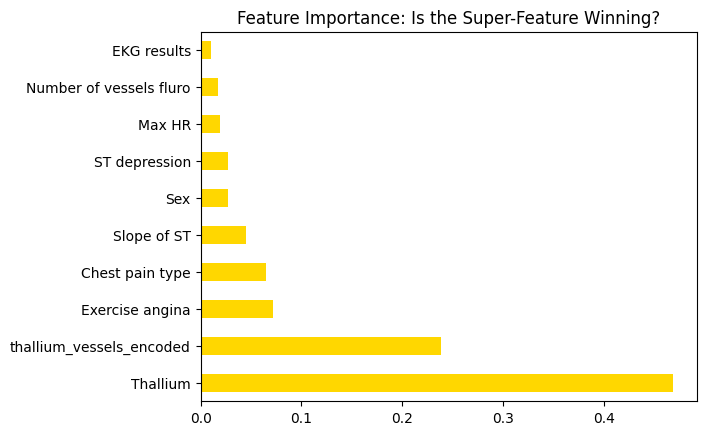

In [64]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- STEP 1: DATA INTEGRITY & FEATURE SELECTION ---
# 1. Drop the 1 NaN in the target and force to Integer (prevents ValueError)
train_df = train_df.dropna(subset=['y'])
train_df['y'] = train_df['y'].astype(int)

# 2. EXPLICIT FEATURE LIST (No more [1:-1] slicing!)
# This ensures 'thallium_vessels_encoded' is the star of the show
FINAL_FEATURES = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro',
    'Thallium',
    'thallium_vessels_encoded' # <--- THE 0.83 SWING FEATURE
]

X_train = train_df[FINAL_FEATURES]
y_train = train_df['y']

# --- STEP 2: OPTIMIZED SEARCH ---
# 1. Subsample 10% for the search phase (60k rows)
X_sample = X_train.sample(frac=0.1, random_state=42)
y_sample = y_train.sample(frac=0.1, random_state=42)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 6],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=6,
    cv=3,
    scoring='accuracy',
    verbose=1
)

print("🚀 Running search with Super-Feature included...")
xgb_search.fit(X_sample, y_sample)

# --- STEP 3: FINAL TRAINING ---
best_params = xgb_search.best_params_
print(f"💪 Training final Champion with params: {best_params}")

final_xgb = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
final_xgb.fit(X_train, y_train)

# --- STEP 4: RESULTS & VISUALIZATION ---
train_acc = final_xgb.score(X_train, y_train)
cv_acc = xgb_search.best_score_

print("-" * 30)
print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Best CV Accuracy: {cv_acc:.4f}")
print(f"The 'Gap': {train_acc - cv_acc:.4f}")
print("-" * 30)

# Verify the King of Features
feat_importances = pd.Series(final_xgb.feature_importances_, index=FINAL_FEATURES)
feat_importances.nlargest(10).plot(kind='barh', color='gold')
plt.title("Feature Importance: Is the Super-Feature Winning?")
plt.show()

## Make Predictions

### Subtask:
Use the trained logistic regression model to make predictions on the preprocessed test data.


**Reasoning**:
The next step is to use the trained logistic regression model to make probability predictions on the preprocessed test data (`X_test`), extracting the probabilities for the positive class as specified.



In [66]:
# 1. Create the cross-feature in the test set
test_df['thallium_vessels_cross'] = (
    test_df['Thallium'].astype(str) + "_" +
    test_df['Number of vessels fluro'].astype(str)
)

# 2. Create a "Safe Map" from your trained encoder
# This creates a dictionary of all known categories and their numbers
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))

# 3. Apply the map safely
# .get(x, -1) means: "If you know the category, give me its number.
# If it's a new category like '3_3', give me -1."
test_df['thallium_vessels_encoded'] = test_df['thallium_vessels_cross'].apply(lambda x: le_dict.get(x, -1))

# 4. Define the final features exactly as they were in training
FINAL_FEATURES = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro',
    'Thallium',
    'thallium_vessels_encoded'
]

X_test_final = test_df[FINAL_FEATURES]

# 5. Generate predictions
print("📊 Generating safe predictions for Kaggle...")
test_predictions_proba = final_xgb.predict_proba(X_test_final)[:, 1]

# 6. Create the submission file
submission_df = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': test_predictions_proba
})

submission_df.to_csv('submission_safe.csv', index=False)

print("-" * 30)
print("✅ FIXED: Unseen labels handled gracefully.")
print(f"New submission saved to 'submission_safe.csv'")
print(submission_df.head())

📊 Generating safe predictions for Kaggle...
------------------------------
✅ FIXED: Unseen labels handled gracefully.
New submission saved to 'submission_safe.csv'
       id  Heart Disease
0  630000       0.580907
1  630001       0.010037
2  630002       0.807298
3  630003       0.006264
4  630004       0.088075


## Generate Submission File

### Subtask:
Create a Kaggle submission file in the specified format, typically with an 'Id' column from the test set and the predicted target values.


**Reasoning**:
To generate the submission file, I will create a pandas DataFrame with 'id' from `test_ids` and 'Heart Disease' from `test_predictions_proba`, then save it to a CSV file and display its head for verification.

